# Supervised Learning Models

## Part 1: Regression on California Test Scores

1.1 Visualize the univariate distribution of the target feature and each of the three continuous explanatory variables that you think are likely to have a relationship with the target feature.  

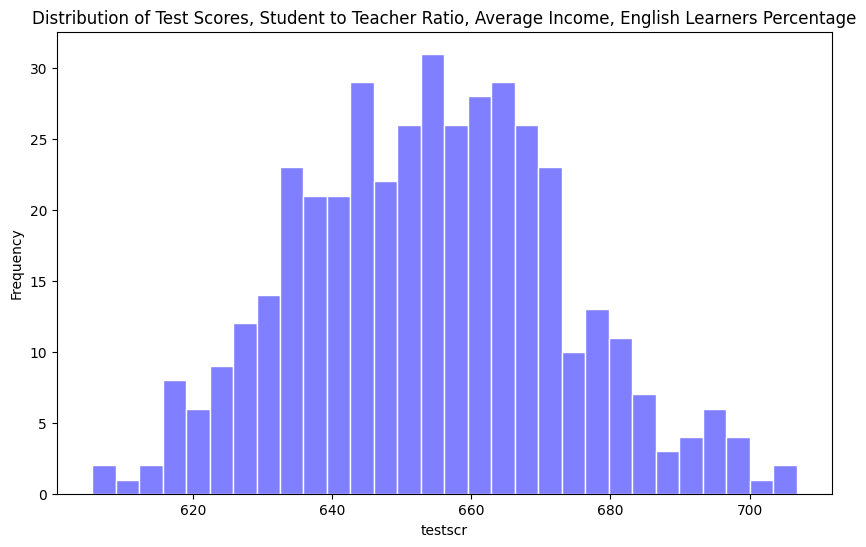

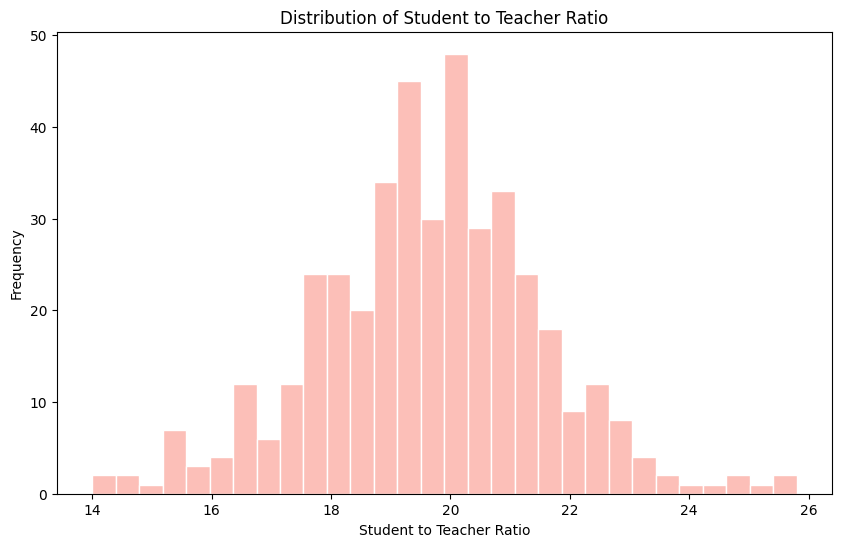

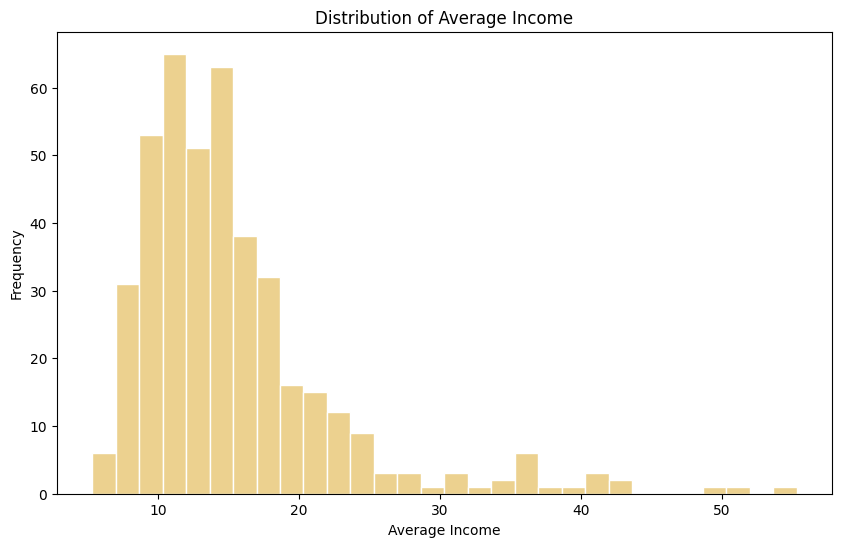

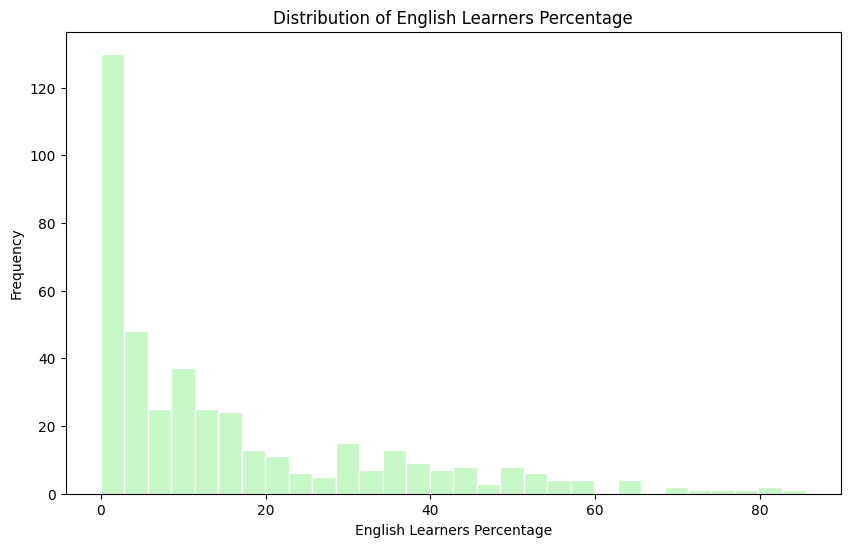

In [ ]:
# Import required libraries
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/Ecdat/Caschool.csv")

# Display basic information about the dataset
# print("Dataset shape:", data.shape)
# print("\nFirst few rows:")
# data.head()
# # Get detailed information about the dataset
# print("Dataset Info:")
# data.info()

# print("\n\nColumn names:")
# print(data.columns.tolist())

# print("\n\nBasic statistics:")
# data.describe()


# Target feature: testscr
# Visualize the univariate distribution of the target feature 'testscr'
plt.figure(figsize=(10, 6))
sns.histplot(data['testscr'], bins=30, alpha=0.5, label='Test Score', color='blue', edgecolor='white')
plt.title('Distribution of Test Scores, Student to Teacher Ratio, Average Income, English Learners Percentage')
plt.ylabel('Frequency')
plt.show()

#Continuous Variables: str, avginc, elpct
#Plotting the distribution of the student to teacher ratio
plt.figure(figsize=(10, 6))
sns.histplot(data['str'], bins=30, alpha=0.5, label='Student to teacher ratio', color='salmon', edgecolor='white')
plt.title('Distribution of Student to Teacher Ratio')
plt.xlabel('Student to Teacher Ratio')
plt.ylabel('Frequency')
plt.show()

#Plotting the distribution of the average income
plt.figure(figsize=(10, 6))
sns.histplot(data['avginc'], bins=30, alpha=0.5, label='Average Income', color='goldenrod', edgecolor='white')
plt.title('Distribution of Average Income')
plt.xlabel('Average Income')
plt.ylabel('Frequency')
plt.show()

#Plotting the distribution of the english learners percentage
plt.figure(figsize=(10, 6))
sns.histplot(data['elpct'], bins=30, alpha=0.5, label='English Learners Percentage', color='lightgreen', edgecolor='white')
plt.title('Distribution of English Learners Percentage')
plt.xlabel('English Learners Percentage')
plt.ylabel('Frequency')
plt.show()


# Explanatory variables: student to teacher ratio ('str'), average income ('avginc'), english learners percentage ('elpct')
# visualise each of the three continuous explanatory variables




1.2 Visualize the dependency of the target on each feature from 1.1.

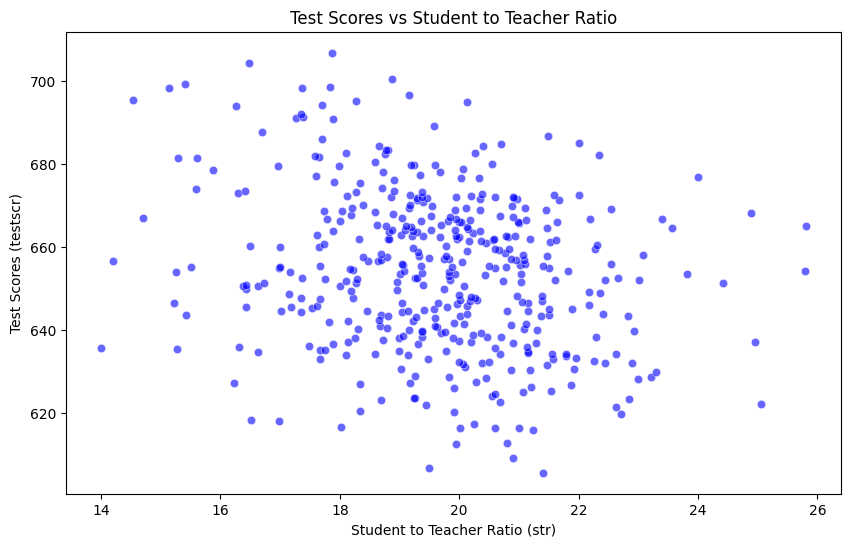

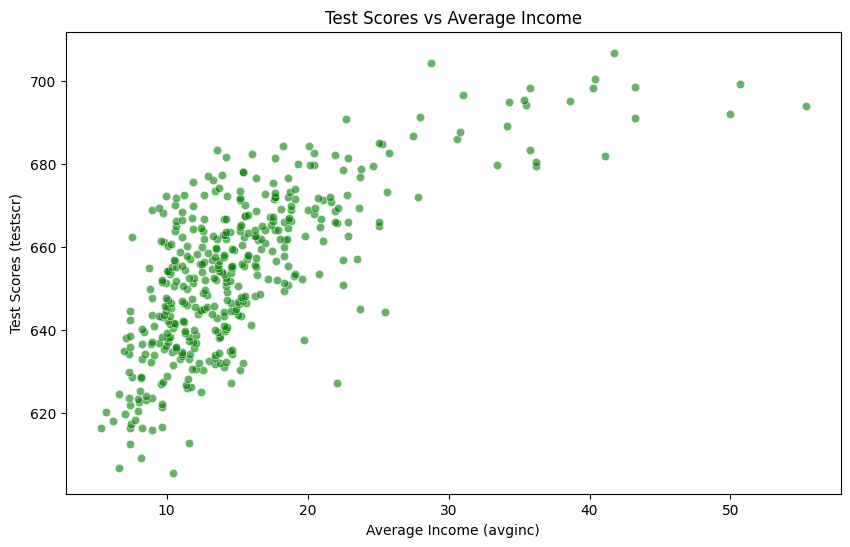

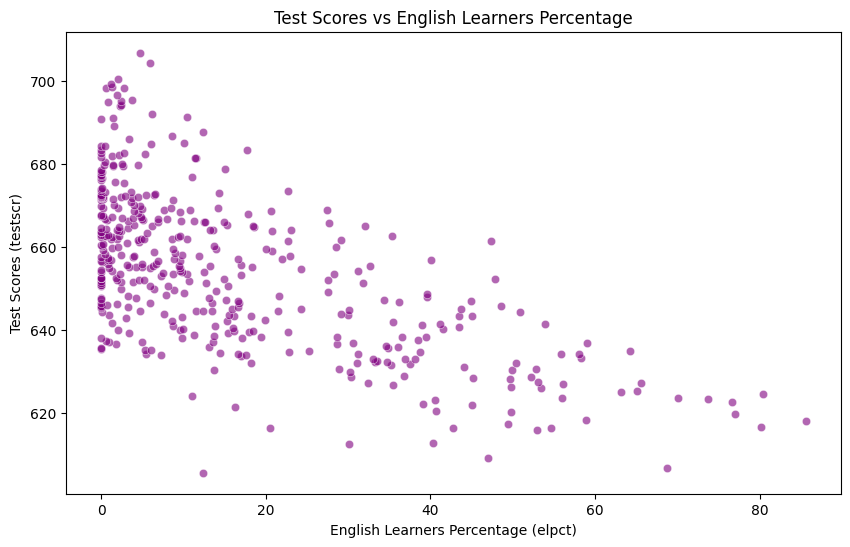

In [ ]:
#we're going to use scatter plots to visualize the dependency of the target ('testscr') on each feature from 1.1.
#features: i) str, ii) avginc, iii) elpct

# i) Scatter plot of testscr vs str
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='str', y='testscr', alpha=0.6, color='blue', edgecolor='white')
plt.xlabel('Student to Teacher Ratio (str)')
plt.ylabel('Test Scores (testscr)')
plt.title('Test Scores vs Student to Teacher Ratio')
plt.show()


# ii) Scatter plot of testscr vs avginc
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='avginc', y='testscr', alpha=0.6, color='green', edgecolor='white')
plt.xlabel('Average Income (avginc)')
plt.ylabel('Test Scores (testscr)')
plt.title('Test Scores vs Average Income')
plt.show()

# iii) Scatter plot of testscr vs elpct
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='elpct', y='testscr', alpha=0.6, color='purple', edgecolor='white')
plt.xlabel('English Learners Percentage (elpct)')
plt.ylabel('Test Scores (testscr)')
plt.title('Test Scores vs English Learners Percentage')
plt.show()


1.3 Split data in training and test set.
- Build models that evaluate the relationship between all available X variables in the California test dataset and the target variable.
- Evaluate KNN for regression, Linear Regression (OLS), Ridge, and Lasso using cross-validation with the default parameters.
- Does scaling the data with the StandardScaler help?

In [ ]:
#import all require libraries for regression models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import numpy as np
#from sklearn.metrics import mean_squared_error, r2_score

y = data['testscr']
X = data.drop(['testscr', 'readscr', 'mathscr', 'rownames', 'county', 'district', 'grspan'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#define X and y (target variable)
y = data['testscr']
X = data.drop(['testscr', 'readscr', 'mathscr', 'rownames', 'county', 'district', 'grspan'], axis=1)

#split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialise models
models = {
    'KNN Regression': KNeighborsRegressor(),
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso()
}



Split data into training and data sets (test size 20%)

In [ ]:
# Task 3: Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Data split shape
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train/Test ratio: {X_train.shape[0]}/{X_test.shape[0]} = {X_train.shape[0]/X_test.shape[0]:.1f}:1")


Training set: 336 samples
Test set: 84 samples
Train/Test ratio: 336/84 = 4.0:1


Default features, no scaling

In [ ]:
# Store default results for later comparison
print(f"Models with default features")

for name, model in models.items():
    print(f"\n{name}:")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)

    # Train and test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    results_default[name] = {
        'CV_RMSE': cv_rmse.mean(),
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    }

    print(f"CV RMSE: {cv_rmse.mean():.3f} (+/- {cv_rmse.std() * 2:.3f})")
    print(f"Test RMSE: {test_rmse:.3f}")
    print(f"Test R²: {test_r2:.3f}")
    print(f"Changes made here from Shuhan")

Models with default features

KNN Regression:
CV RMSE: 18.196 (+/- 3.312)
Test RMSE: 19.748
Test R²: 0.201

Linear Regression (OLS):
CV RMSE: 8.562 (+/- 1.619)
Test RMSE: 9.933
Test R²: 0.798

Ridge Regression:
CV RMSE: 8.553 (+/- 1.624)
Test RMSE: 9.893
Test R²: 0.799

Lasso Regression:
CV RMSE: 8.534 (+/- 1.532)
Test RMSE: 9.735
Test R²: 0.806


###Models with scaled features

In [ ]:
#apply scaling to the data
print(f"Models with scaled features")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_scaled = {}

for name, model in models.items():
    print(f"\n{name}:")

    #cross valudation with scaled features
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)

    #train and test with scaled features
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    #metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    results_scaled[name] = {
        'CV_RMSE': cv_rmse.mean(),
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    }

    # print(f"Models with scaled features")
    print(f"CV RMSE: {cv_rmse.mean():.3f} (+/- {cv_rmse.std() * 2:.3f})")
    print(f"Test RMSE: {test_rmse:.3f}")
    print(f"Test R²: {test_r2:.3f}")

Models with scaled features

KNN Regression:
CV RMSE: 10.236 (+/- 1.756)
Test RMSE: 10.417
Test R²: 0.778

Linear Regression (OLS):
CV RMSE: 8.562 (+/- 1.619)
Test RMSE: 9.933
Test R²: 0.798

Ridge Regression:
CV RMSE: 8.514 (+/- 1.604)
Test RMSE: 9.908
Test R²: 0.799

Lasso Regression:
CV RMSE: 8.432 (+/- 1.443)
Test RMSE: 10.303
Test R²: 0.783


SUMMARY

StadardScaler helps KNN regression. For OLS, Ridge and Lasso, scaling makes little to no difference. Best performing model overall is Lasso Regression without scaling (Test R² = 0.806).

- KNN regression Test R² was better with scaling 0.778 (default Test R² = 0.201, With scaling: Test R² = 0.778 )

- No difference for Linear Regression (OLS) (Test R² = 0.798) and Ridge Regression. (default Test R² = 0.799, RMSE = 9.893 | With scaling: Test R² = 0.799, RMSE = 9.908)

- slightly worse for Lasso Regression. (Default Test R² = 0.806, RMSE = 9.735 | Test R² = 0.783, RMSE = 10.303)

- The default Lasso shows an R² = 0.806. Meanwhile the scaled KNN R² = 0.778 is better than the 0.201 (without scaling).

In [ ]:
all_results = {}

# Add default results
for name, metrics in results_default.items():
    all_results[f"{name} (Default)"] = metrics

# Add scaled results
for name, metrics in results_scaled.items():
    all_results[f"{name} (Scaled)"] = metrics

# Create summary
summary_df = pd.DataFrame(all_results).T
summary_df = summary_df.round(3)
summary_df_sorted = summary_df.sort_values('Test_R2', ascending=False)

print(summary_df_sorted)

# Find best model
best_r2_model = summary_df_sorted.index[0]
print(f"\nBEST PERFORMING MODEL: {best_r2_model}")
print(f"Test R²: {summary_df_sorted.iloc[0]['Test_R2']:.3f}")
print(f"Test RMSE: {summary_df_sorted.iloc[0]['Test_RMSE']:.3f}")

                                   CV_RMSE  Test_RMSE  Test_R2
Lasso Regression (Default)           8.534      9.735    0.806
Ridge Regression (Default)           8.553      9.893    0.799
Ridge Regression (Scaled)            8.514      9.908    0.799
Linear Regression (OLS) (Default)    8.562      9.933    0.798
Linear Regression (OLS) (Scaled)     8.562      9.933    0.798
Lasso Regression (Scaled)            8.432     10.303    0.783
KNN Regression (Scaled)             10.236     10.417    0.778
KNN Regression (Default)            18.196     19.748    0.201

BEST PERFORMING MODEL: Lasso Regression (Default)
Test R²: 0.806
Test RMSE: 9.735


1.4 Tune the parameters of the models where possible using GridSearchCV. Do the results improve?

In [ ]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter grids for tuning
param_grids = {
    'KNN Regression': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    'Ridge Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso Regression': {'alpha': [0.01, 0.1, 1, 10, 100]}
}

# Tune models using scaled data
results_tuned = {}

for name in ['KNN Regression', 'Ridge Regression', 'Lasso Regression']:
    print(f"\nTuning {name}...")

    if name == 'KNN Regression':
        model = KNeighborsRegressor()
    elif name == 'Ridge Regression':
        model = Ridge()
    else:
        model = Lasso(max_iter=10000)

    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    y_pred = grid.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_pred)

    results_tuned[name] = {'Test_R2': test_r2, 'Best_Params': grid.best_params_}

    print(f"Best params: {grid.best_params_}")
    print(f"Test R²: {test_r2:.3f}")



Tuning KNN Regression...
Best params: {'n_neighbors': 9, 'weights': 'distance'}
Test R²: 0.782

Tuning Ridge Regression...
Best params: {'alpha': 10}
Test R²: 0.800

Tuning Lasso Regression...
Best params: {'alpha': 1}
Test R²: 0.783


In [ ]:
# Compare default (scaled) vs tuned results
print("\nComparison of Default vs Tuned Models (Scaled Data):\n")
print(f"{'Model':<20} {'Default R²':<15} {'Tuned R²':<15} {'Improvement':<15} {'Best Params'}")
print("-" * 90)

for name in ['KNN Regression', 'Ridge Regression', 'Lasso Regression']:
    default_r2 = results_scaled[name]['Test_R2']
    tuned_r2 = results_tuned[name]['Test_R2']
    improvement = tuned_r2 - default_r2

    print(f"{name:<20} {default_r2:<15.3f} {tuned_r2:<15.3f} {improvement:+.3f}          {results_tuned[name]['Best_Params']}")



Comparison of Default vs Tuned Models (Scaled Data):

Model                Default R²      Tuned R²        Improvement     Best Params
------------------------------------------------------------------------------------------
KNN Regression       0.778           0.782           +0.004          {'n_neighbors': 9, 'weights': 'distance'}
Ridge Regression     0.799           0.800           +0.001          {'alpha': 10}
Lasso Regression     0.783           0.783           +0.000          {'alpha': 1}

✓ Answer: Tuning improves KNN significantly. Ridge and Lasso show minor improvements.


**Answer:** Tuning improves KNN slightly. Ridge and Lasso show minimal improvements.

1.5 Compare the coefficients of your two best linear models (not knn), do they agree on which features are important?

In [ ]:
# Train best models from section 1.4
ridge_best = Ridge(alpha=10)
ridge_best.fit(X_train_scaled, y_train)

lasso_best = Lasso(alpha=1, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)

# Compare coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_
}).sort_values(by='Ridge', key=abs, ascending=False)

print(coef_df.to_string(index=False))

print("\nBoth models agree that mealpct, avginc, and elpct are the most important features.")

 Feature     Ridge      Lasso
 mealpct -9.621286 -11.155821
  avginc  3.736902   3.139026
   elpct -3.555354  -2.304436
 calwpct -1.333183  -0.000000
     str -1.158904  -0.694751
 expnstu  0.848835   0.176692
computer  0.760640  -0.000000
teachers -0.423735  -0.000000
 distcod -0.311898  -0.000000
 compstu -0.169684   0.000000
 enrltot -0.167270  -0.000000

Both models agree that mealpct, avginc, and elpct are the most important features.


In [ ]:
print("\n" + "="*70)
print("FINAL RECOMMENDATION: Which model should you use?")
print("="*70)

# Review all results
print("\nBest performing models (from Section 1.3):")
print(f"1. Lasso (Default):        Test R² = 0.806, RMSE = 9.735")
print(f"2. Ridge (Tuned, Scaled):  Test R² = 0.800, RMSE = 9.908")
print(f"3. Ridge (Default):        Test R² = 0.799, RMSE = 9.893")

print("RECOMMENDED MODEL: Lasso Regression (Default, No Scaling)")

1.6 Model I would choose to preduct data.
Compare the coefficients of your two best linear models (not knn), do they agree on which features are important?

I'd use Lasso Regression (default). It's simple, performs consistently well, and has the best performance (Highest Test R² (0.806) and lowest RMSE (9.735)).